# Vetting the new reference genome release
The people behind the new genome release included a [txt file](https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/053/477/285/GCF_053477285.1_ASM5347728v1/Annotation_comparison/GCF_053477285.1_ASM5347728v1_compare_prev.txt.gz) to compare annotations in the old and new genome.

Here, I'm going to take a look at this through exploratory analysis.

## 0. load libraries

In [2]:
library(tidyverse)

## 2. load files

In [3]:
annot <- read.csv('/scratch4/workspace/julia_mcdonough_student_uml_edu-novogene_dwnld/GCF_053477285.1_ASM5347728v1_compare_prev.txt', sep = '\t')
head(annot)

,X.gene.category,current.GeneID,current.gene.biotype,current.assembly.unit,current.genomic.accession,current.gene.range,current.gene.strand,previous.GeneID,previous.gene.biotype,previous.assembly.unit,previous.genomic.accession,previous.gene.range,previous.gene.strand,transcript.category,current.transcript.accession,current.protein.accession,current.transcript.range,previous.transcript.accession,previous.protein.accession,previous.transcript.range
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Current-unmapped,144622103,protein_coding,GCF_053477295.1,NC_136047.1,10011040-10016688,-,NA,NA,NA,NA,NA,NA,Current-unmapped,XM_078466607.1,XP_078322733.1,10011040-10016688,NA,NA,NA
2,Current-unmapped,144622104,protein_coding,GCF_053477295.1,NC_136047.1,10021967-10029276,-,NA,NA,NA,NA,NA,NA,Current-unmapped,XM_078466608.1,XP_078322734.1,10021967-10029276,NA,NA,NA
3,Current-unmapped,144620484,pseudogene,GCF_053477295.1,NC_136047.1,10032360-10033427,-,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Current-unmapped,144620485,pseudogene,GCF_053477295.1,NC_136047.1,10034020-10034731,-,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Current-unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,NA,NA,NA,NA,NA,Current-unmapped,XM_078466604.1,XP_078322730.1,10038273-10045134,NA,NA,NA
6,Current-unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,NA,NA,NA,NA,NA,Current-unmapped,XM_078466605.1,XP_078322731.1,10038273-10045181,NA,NA,NA


## 3. exploratory analysis

In [4]:
dim(annot) 

[1] 97934    20

97,934 rows - since there are only 35K-ish genes in the *C. virginica* genome, this doesn't necessarily mean one row = one gene

### gene categories

In [5]:
unique(annot$X.gene.category)

[1] "Current-unmapped"      "Current-novel"         "Changed locus ID"     
 [4] "Similar"               "Changed substantially" "Current-other"        
 [7] "Changed locus type"    "Identical"             "Merged"               
[10] "Split"                 "Other"                 "Changed completeness" 
[13] "Previous-other"        "Previous-unmapped"     "Previous-novel"

I'm not too sure what each of these mean ... here's what I can find:

**high-confidence matches**
- Similar: very similar gene, small differences only
- Identical: same gene model (exon structure and boundaries match perfectly)

**structural or annotation changes**
- Changed substantially: same locus but major differences (exon structure changed a lot, low overlap)
- Changed locus type: gene biotype changed (e.g., protein-coding -> psuedogene)
- Changed completeness: model completeness changed (e.g., gained/lost start/stop codon, partial <-> full length)
- Changed locus ID: gene identifier reassigned (often due to merging/splitting/reclassification)
- Split: one previous gene became multiple genes in current annotation
- Merged: multiple previous genes combined in one current gene

**newly appearing genes (no match previously)**
- Current-unmapped: couldn't be mapped to previous assembly (e.g., assembly changed or region is absent - not necessarily biologically "new")
- Current-novel: newly discovered genes
- Current-other: new genes that don't fit cleanly into the above categories

**disappearing genes (present before, gone now)**
- Previous-unmapped: couldn't be mapped to current assembly (lost or heavily rearranged in new assembly)
- Previous-novel: previous gene annotations that don't have a counterpart in this new assembly ("disappearing genes")
- Previous-other: genes that don't fit cleanly into the above categories

**catch-all/misc.**
- Other

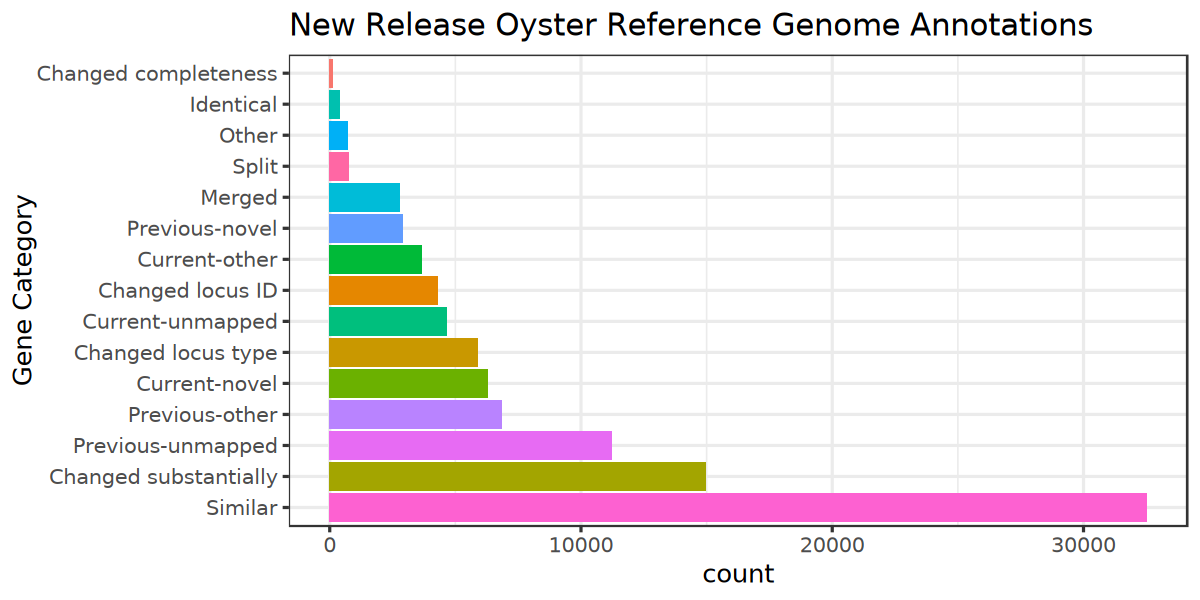

In [6]:
options(repr.plot.height = 5, repr.plot.width = 10)

ggplot(annot, aes(x = fct_infreq(X.gene.category), fill = X.gene.category)) +
geom_bar() +
coord_flip() +
theme_bw(base_size = 15) +
theme(legend.position = 'none') +
labs(x = 'Gene Category', title = 'New Release Oyster Reference Genome Annotations')

so the majority of the gene annotations are similar to the previous gene - i'm curious to split these other categories up more

In [14]:
annot2 <- annot %>%
  separate(X.gene.category,
           into = c("status", "type"),
           sep = "-",
           fill = "left",
          remove = FALSE) %>%
mutate(status = ifelse(is.na(status), 'Both', status))

head(annot2)

,X.gene.category,status,type,current.GeneID,current.gene.biotype,current.assembly.unit,current.genomic.accession,current.gene.range,current.gene.strand,previous.GeneID,⋯,previous.genomic.accession,previous.gene.range,previous.gene.strand,transcript.category,current.transcript.accession,current.protein.accession,current.transcript.range,previous.transcript.accession,previous.protein.accession,previous.transcript.range
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Current-unmapped,Current,unmapped,144622103,protein_coding,GCF_053477295.1,NC_136047.1,10011040-10016688,-,NA,⋯,NA,NA,NA,Current-unmapped,XM_078466607.1,XP_078322733.1,10011040-10016688,NA,NA,NA
2,Current-unmapped,Current,unmapped,144622104,protein_coding,GCF_053477295.1,NC_136047.1,10021967-10029276,-,NA,⋯,NA,NA,NA,Current-unmapped,XM_078466608.1,XP_078322734.1,10021967-10029276,NA,NA,NA
3,Current-unmapped,Current,unmapped,144620484,pseudogene,GCF_053477295.1,NC_136047.1,10032360-10033427,-,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Current-unmapped,Current,unmapped,144620485,pseudogene,GCF_053477295.1,NC_136047.1,10034020-10034731,-,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Current-unmapped,Current,unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,⋯,NA,NA,NA,Current-unmapped,XM_078466604.1,XP_078322730.1,10038273-10045134,NA,NA,NA
6,Current-unmapped,Current,unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,⋯,NA,NA,NA,Current-unmapped,XM_078466605.1,XP_078322731.1,10038273-10045181,NA,NA,NA


**current** = info from the new reference

**previous** = info from the old reference

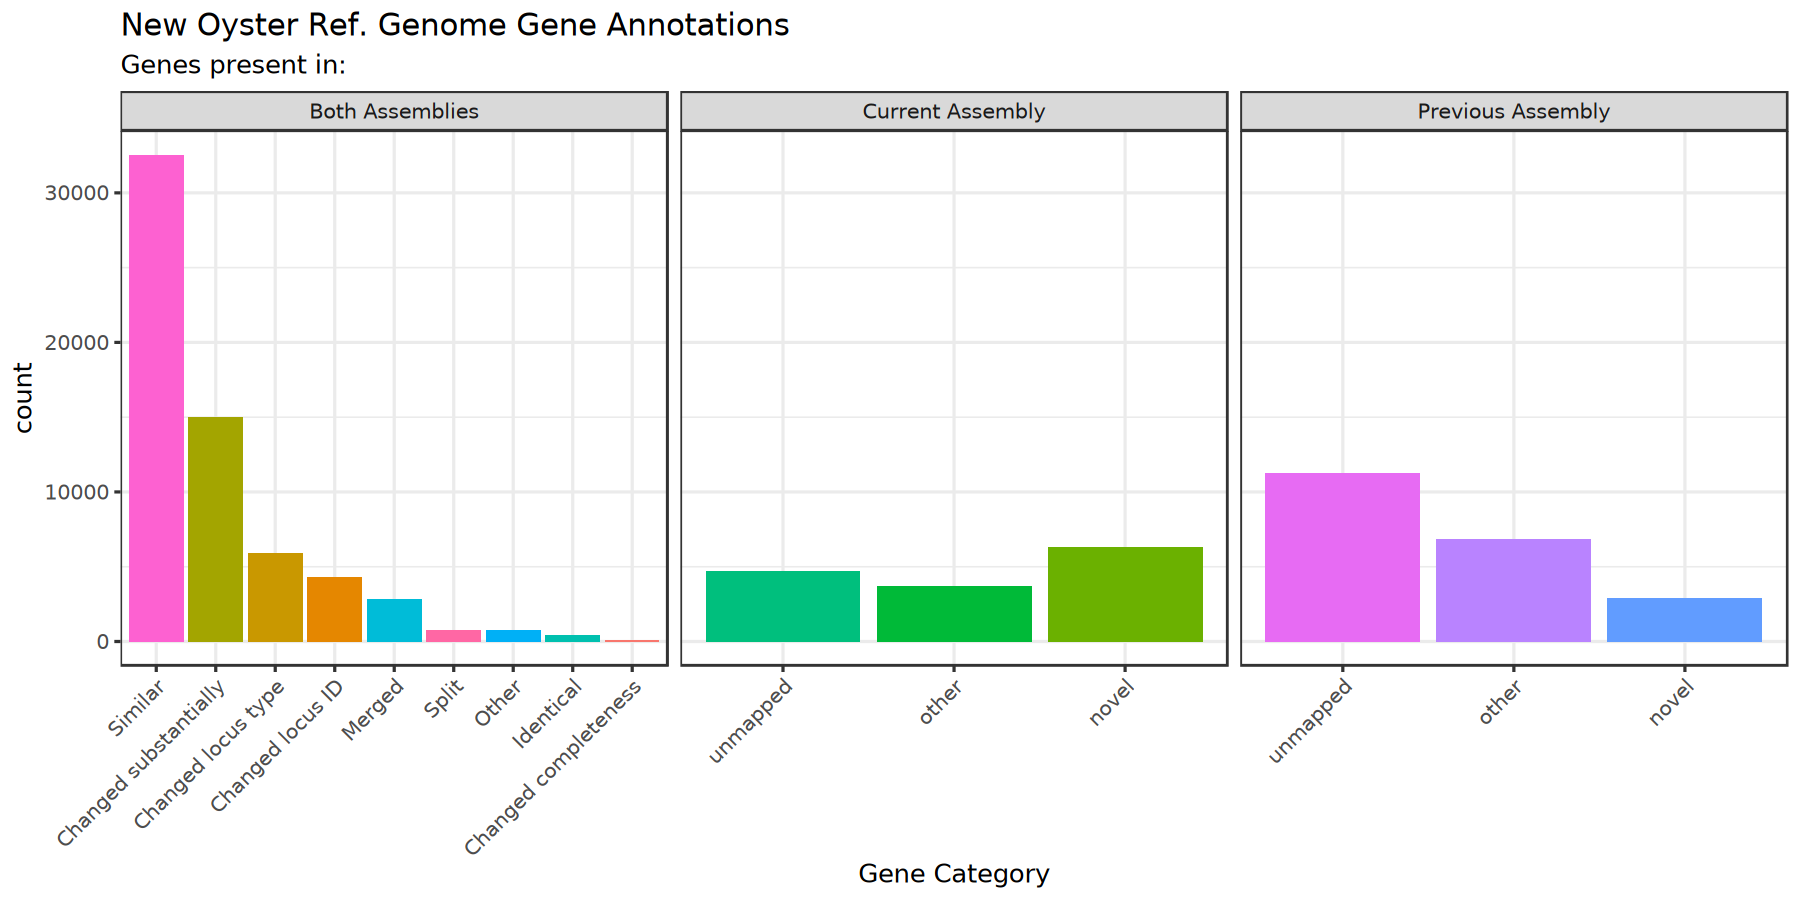

In [22]:
options(repr.plot.height = 7.5, repr.plot.width = 15)

ggplot(annot2, aes(x = fct_infreq(type), fill = X.gene.category)) +
geom_bar() +
facet_wrap(~status, scales = 'free_x', nrow = 1,
           labeller = labeller(
               status = c(
        "Current" = "Current Assembly",
        "Previous" = "Previous Assembly",
        "Both" = "Both Assemblies"
      )
    )) +
theme_bw(base_size = 15) +
theme(legend.position = 'none',
     axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = 'Gene Category', 
     title = 'New Oyster Ref. Genome Gene Annotations',
    subtitle = 'Genes present in:')

What does this tell us?
- most genes are similar to the previous annotation (yay!)
- there are more removed genes than there are new genes (copmaring current box to previous box)
    - the majority of the removed genes didn't align to the new assembly
    - the majority of the new genes are new annotations that don't have a counterpart in the previous genome

### transcript categories

In [27]:
unique(annot2$transcript.category)

[1] "Current-unmapped"            NA                           
 [3] "Current-novel"               "Previous-other"             
 [5] "Change in exception"         "Previous-variant"           
 [7] "Similar, change in UTR only" "Variant"                    
 [9] "Similar, change in CDS"      "Changed substantially"      
[11] "Current-other"               "Other"                      
[13] "Similar"                     "Merged"                     
[15] "Changed feature type"        "Previous-unmapped"          
[17] "Changed locus ID"            "Split"                      
[19] "Previous-novel"              "Identical"

from looking at the df, all NAs are either pseudogenes, protein-coding, or tRNAs in the current genome - most aren't found in the previous assembly

In [29]:
annot3 <- annot2 %>%
  separate(transcript.category,
           into = c("status_t", "type_t"),
           sep = "-",
           fill = "left",
          remove = FALSE) %>%
mutate(status_t = ifelse(is.na(status_t), 'Both', status_t))

head(annot3)

,X.gene.category,status,type,current.GeneID,current.gene.biotype,current.assembly.unit,current.genomic.accession,current.gene.range,current.gene.strand,previous.GeneID,⋯,previous.gene.strand,transcript.category,status_t,type_t,current.transcript.accession,current.protein.accession,current.transcript.range,previous.transcript.accession,previous.protein.accession,previous.transcript.range
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Current-unmapped,Current,unmapped,144622103,protein_coding,GCF_053477295.1,NC_136047.1,10011040-10016688,-,NA,⋯,NA,Current-unmapped,Current,unmapped,XM_078466607.1,XP_078322733.1,10011040-10016688,NA,NA,NA
2,Current-unmapped,Current,unmapped,144622104,protein_coding,GCF_053477295.1,NC_136047.1,10021967-10029276,-,NA,⋯,NA,Current-unmapped,Current,unmapped,XM_078466608.1,XP_078322734.1,10021967-10029276,NA,NA,NA
3,Current-unmapped,Current,unmapped,144620484,pseudogene,GCF_053477295.1,NC_136047.1,10032360-10033427,-,NA,⋯,NA,NA,Both,NA,NA,NA,NA,NA,NA,NA
4,Current-unmapped,Current,unmapped,144620485,pseudogene,GCF_053477295.1,NC_136047.1,10034020-10034731,-,NA,⋯,NA,NA,Both,NA,NA,NA,NA,NA,NA,NA
5,Current-unmapped,Current,unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,⋯,NA,Current-unmapped,Current,unmapped,XM_078466604.1,XP_078322730.1,10038273-10045134,NA,NA,NA
6,Current-unmapped,Current,unmapped,144622102,protein_coding,GCF_053477295.1,NC_136047.1,10038273-10045182,-,NA,⋯,NA,Current-unmapped,Current,unmapped,XM_078466605.1,XP_078322731.1,10038273-10045181,NA,NA,NA


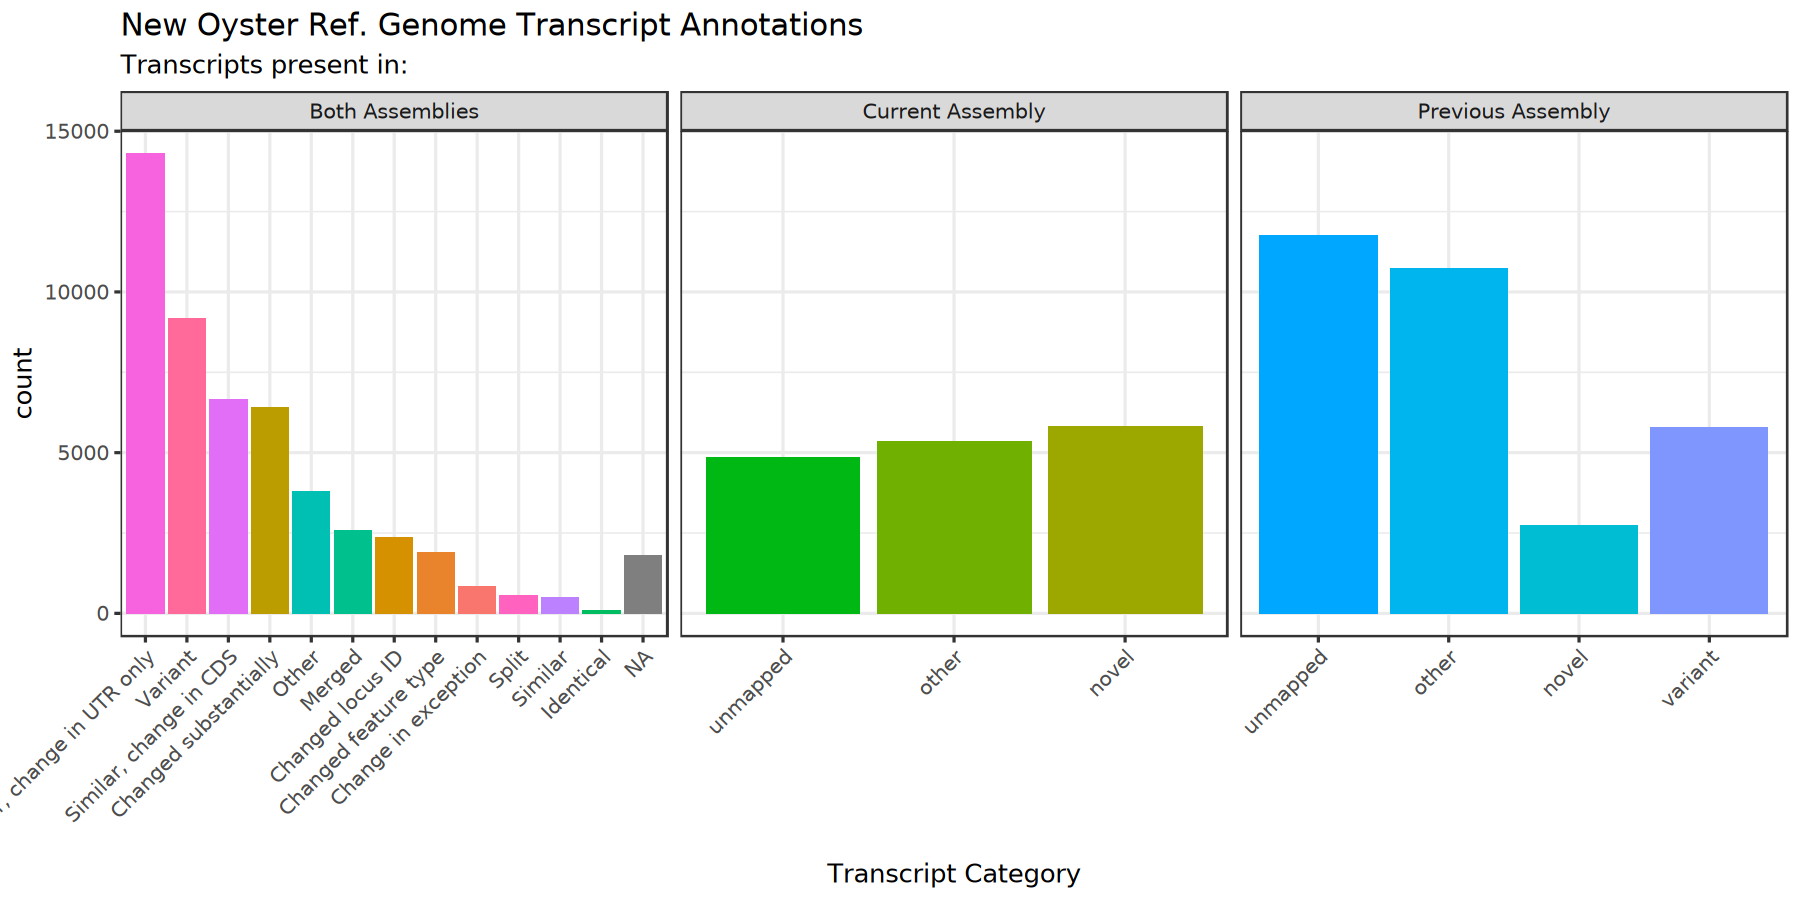

In [36]:
ggplot(annot3, aes(x = fct_infreq(type_t), fill = transcript.category)) +
geom_bar() +
theme_bw(base_size = 15) +
facet_wrap(~status_t, scales = 'free_x', nrow = 1,
           labeller = labeller(
               status_t = c(
        "Current" = "Current Assembly",
        "Previous" = "Previous Assembly",
        "Both" = "Both Assemblies"
      )
    )) +
theme(legend.position = 'none',
     axis.text.x = element_text(angle = 45, hjust = 1)) +
labs(x = 'Transcript Category', 
     title = 'New Oyster Ref. Genome Transcript Annotations',
    subtitle = 'Transcripts present in:')